# Module 9: FFT and Pattern Matching



**CSC 821 - Group 1**  

**Author:** Enyoni



## Objectives



This notebook implements the Fast Fourier Transform (FFT) from scratch and uses it to analyze a test signal. It also implements and compares Naive Search, Knuth-Morris-Pratt (KMP), and Boyer-Moore exact pattern matching. Code, demonstrations, validation, plots,

In [19]:
import cmath

from collections.abc import Sequence



import matplotlib.pyplot as plt

import numpy as np



plt.style.use("seaborn-v0_8-whitegrid")

## Part 1: Fast Fourier Transform



Run the cells below to define the recursive radix-2 FFT and analyze the test signal.

In [20]:
def fft(samples: Sequence[complex]) -> list[complex]:

    """Return the DFT of samples using the recursive radix-2 FFT algorithm."""

    sample_count = len(samples)

    if sample_count == 0 or sample_count & (sample_count - 1):

        raise ValueError("FFT input length must be a non-zero power of two")

    if sample_count == 1:

        return [complex(samples[0])]



    even_spectrum = fft(samples[0::2])

    odd_spectrum = fft(samples[1::2])

    spectrum = [0j] * sample_count



    for frequency_index in range(sample_count // 2):

        twiddle = cmath.exp(-2j * cmath.pi * frequency_index / sample_count)

        odd_component = twiddle * odd_spectrum[frequency_index]

        spectrum[frequency_index] = even_spectrum[frequency_index] + odd_component

        spectrum[frequency_index + sample_count // 2] = (

            even_spectrum[frequency_index] - odd_component

        )



    return spectrum

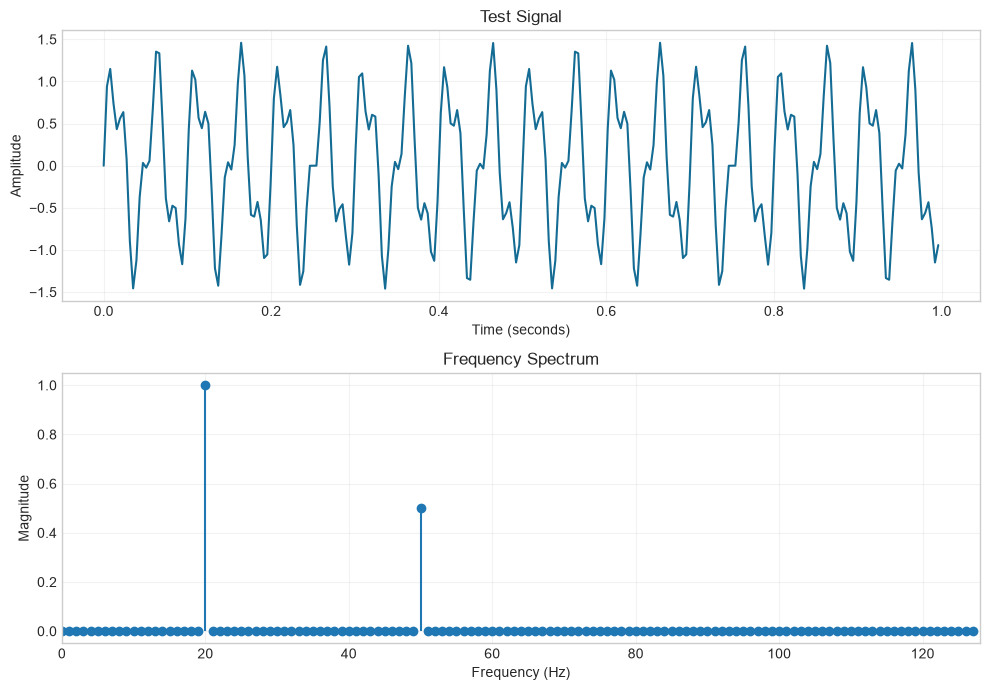

Dominant frequencies: 20 Hz, 50 Hz


In [21]:
sample_rate = 256

duration = 1.0

times = np.arange(0, duration, 1 / sample_rate)

signal = np.sin(2 * np.pi * 20 * times) + 0.5 * np.sin(2 * np.pi * 50 * times)



spectrum = np.asarray(fft(signal))

frequencies = np.arange(len(signal) // 2) * sample_rate / len(signal)

magnitudes = 2 * np.abs(spectrum[: len(signal) // 2]) / len(signal)



figure, (signal_axis, spectrum_axis) = plt.subplots(2, 1, figsize=(10, 7))

signal_axis.plot(times, signal, color="#146c94")

signal_axis.set(title="Test Signal", xlabel="Time (seconds)", ylabel="Amplitude")

signal_axis.grid(alpha=0.25)



spectrum_axis.stem(frequencies, magnitudes, basefmt=" ")

spectrum_axis.set(

    title="Frequency Spectrum",

    xlabel="Frequency (Hz)",

    ylabel="Magnitude",

    xlim=(0, sample_rate / 2),

)

spectrum_axis.grid(alpha=0.25)

figure.tight_layout()

figure.savefig("fft_signal_spectrum.png", dpi=150)

plt.show()



dominant_indices = np.argsort(magnitudes)[-2:]

dominant_frequencies = sorted(frequencies[dominant_indices])

print("Dominant frequencies:", ", ".join(f"{value:.0f} Hz" for value in dominant_frequencies))

## Part 2: Pattern Matching



Run the cells below to define and compare Naive Search, KMP, and Boyer-Moore.

In [16]:
def naive_search(text: str, pattern: str) -> list[int]:

    """Return all matches by checking the pattern at every valid index."""

    if not pattern:

        return list(range(len(text) + 1))



    return [

        start

        for start in range(len(text) - len(pattern) + 1)

        if text[start : start + len(pattern)] == pattern

    ]





def build_lps(pattern: str) -> list[int]:

    """Build KMP's longest proper prefix which is also a suffix table."""

    lps = [0] * len(pattern)

    prefix_length = 0

    pattern_index = 1



    while pattern_index < len(pattern):

        if pattern[pattern_index] == pattern[prefix_length]:

            prefix_length += 1

            lps[pattern_index] = prefix_length

            pattern_index += 1

        elif prefix_length:

            prefix_length = lps[prefix_length - 1]

        else:

            pattern_index += 1



    return lps





def kmp_search(text: str, pattern: str) -> list[int]:

    """Return all matches using Knuth-Morris-Pratt prefix information."""

    if not pattern:

        return list(range(len(text) + 1))



    lps = build_lps(pattern)

    matches: list[int] = []

    text_index = 0

    pattern_index = 0



    while text_index < len(text):

        if text[text_index] == pattern[pattern_index]:

            text_index += 1

            pattern_index += 1

            if pattern_index == len(pattern):

                matches.append(text_index - pattern_index)

                pattern_index = lps[pattern_index - 1]

        elif pattern_index:

            pattern_index = lps[pattern_index - 1]

        else:

            text_index += 1



    return matches





def boyer_moore_search(text: str, pattern: str) -> list[int]:

    """Return all matches using Boyer-Moore's bad-character rule."""

    if not pattern:

        return list(range(len(text) + 1))



    last_occurrence = {character: index for index, character in enumerate(pattern)}

    matches: list[int] = []

    alignment = 0



    while alignment <= len(text) - len(pattern):

        pattern_index = len(pattern) - 1

        while (

            pattern_index >= 0

            and pattern[pattern_index] == text[alignment + pattern_index]

        ):

            pattern_index -= 1



        if pattern_index < 0:

            matches.append(alignment)

            next_index = alignment + len(pattern)

            alignment += (

                len(pattern) - last_occurrence.get(text[next_index], -1)

                if next_index < len(text)

                else 1

            )

        else:

            mismatched_character = text[alignment + pattern_index]

            alignment += max(

                1,

                pattern_index - last_occurrence.get(mismatched_character, -1),

            )



    return matches

In [17]:
text = "ABAAABCDABCABC"

pattern = "ABC"

algorithms = {

    "Naive": naive_search,

    "KMP": kmp_search,

    "Boyer-Moore": boyer_moore_search,

}



print(f"Text: {text}")

print(f"Pattern: {pattern}")

for name, search in algorithms.items():

    print(f"{name} match indices: {search(text, pattern)}")

Text: ABAAABCDABCABC
Pattern: ABC
Naive match indices: [4, 8, 11]
KMP match indices: [4, 8, 11]
Boyer-Moore match indices: [4, 8, 11]


In [18]:
# Validate the custom FFT against NumPy's trusted implementation.

test_values = np.array([0.0, 1.0, 0.0, -1.0, 0.0, 1.0, 0.0, -1.0])

assert np.allclose(fft(test_values), np.fft.fft(test_values))



# Validate every matcher against a simple reference search.

test_cases = [

    ("ABAAABCDABCABC", "ABC"),

    ("AAAAA", "AAA"),

    ("hello", "xyz"),

    ("", ""),

    ("abc", ""),

]



for test_text, test_pattern in test_cases:

    expected = [

        index

        for index in range(len(test_text) - len(test_pattern) + 1)

        if test_text.startswith(test_pattern, index)

    ]

    for name, search in algorithms.items():

        actual = search(test_text, test_pattern)

        assert actual == expected, (

            f"{name} failed for {test_text=!r}, {test_pattern=!r}: "

            f"expected {expected}, got {actual}"

        )



assert dominant_frequencies == [20.0, 50.0]

print("All FFT and pattern-matching validation checks passed.")

All FFT and pattern-matching validation checks passed.
